In [1]:
# Fixer les seeds pour la reproductibilité
import random
import numpy as np
import torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
print("✅ Seeds fixées à 42")

✅ Seeds fixées à 42


In [2]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print("✅ GPU activé !")
else:
    print("⚠️ CPU uniquement")

PyTorch version: 2.2.1
CUDA disponible: True
GPU: NVIDIA GeForce GTX 1650 with Max-Q Design
✅ GPU activé !


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform
)
test_dataset = datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

print(f"Train samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Train samples: 60000
Test samples: 10000


In [5]:
class MLPScratch(nn.Module):
    def __init__(self, num_inputs, num_outputs, num_hiddens, sigma=0.01):
        super().__init__()
        self.num_inputs = num_inputs
        self.W1 = nn.Parameter(torch.randn(num_inputs, num_hiddens) * sigma)
        self.b1 = nn.Parameter(torch.zeros(num_hiddens))
        self.W2 = nn.Parameter(torch.randn(num_hiddens, num_outputs) * sigma)
        self.b2 = nn.Parameter(torch.zeros(num_outputs))
    
    def forward(self, X):
        X = X.reshape((-1, self.num_inputs))
        H = torch.relu(torch.matmul(X, self.W1) + self.b1)
        return torch.matmul(H, self.W2) + self.b2

In [6]:
class MLPConcise(nn.Module):
    def __init__(self, num_outputs, num_hiddens):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, num_hiddens),
            nn.ReLU(),
            nn.Linear(num_hiddens, num_outputs)
        )
    
    def forward(self, X):
        return self.net(X)

In [7]:
def evaluate_accuracy(model, data_loader, device='cpu'):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.numel()
    return correct / total

In [8]:
def train_model(model, train_loader, test_loader, epochs=10, lr=0.1, device='cpu'):
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    model.to(device)
    
    history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}
    
    print(f"{'Epoch':>6} | {'train_loss':>12} | {'test_loss':>12} | {'test_acc':>10} | {'train_acc':>10}")
    print("-" * 65)
    
    for epoch in range(1, epochs + 1):
        # Entraînement
        model.train()
        total_train_loss = 0
        num_batches = 0
        
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(X)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()
            num_batches += 1
        
        avg_train_loss = total_train_loss / num_batches
        
        # Évaluation
        train_acc = evaluate_accuracy(model, train_loader, device)
        test_acc = evaluate_accuracy(model, test_loader, device)
        
        # Loss de test
        model.eval()
        total_test_loss = 0
        with torch.no_grad():
            for X, y in test_loader:
                X, y = X.to(device), y.to(device)
                logits = model(X)
                loss = criterion(logits, y)
                total_test_loss += loss.item()
        avg_test_loss = total_test_loss / len(test_loader)
        
        history['train_loss'].append(avg_train_loss)
        history['test_loss'].append(avg_test_loss)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)
        
        print(f"{epoch:6d} | {avg_train_loss:12.4f} | {avg_test_loss:12.4f} | {test_acc*100:9.2f}% | {train_acc*100:9.2f}%")
    
    return history

In [9]:
print("\n" + "="*70)
print("ENTRAÎNEMENT MODÈLE FROM SCRATCH (h=256, lr=0.1)")
print("="*70)

model_scratch = MLPScratch(num_inputs=784, num_outputs=10, num_hiddens=256)
history_scratch = train_model(model_scratch, train_loader, test_loader, epochs=10, lr=0.1, device=device)

print(f"\n=== RÉSULTATS FROM SCRATCH ===")
print(f"Train accuracy (finale): {history_scratch['train_acc'][-1]*100:.2f}%")
print(f"Test accuracy (finale):  {history_scratch['test_acc'][-1]*100:.2f}%")
print(f"Gap: {(history_scratch['train_acc'][-1] - history_scratch['test_acc'][-1])*100:.2f}%")
best_idx = history_scratch['test_acc'].index(max(history_scratch['test_acc']))
print(f"Meilleure test accuracy: {history_scratch['test_acc'][best_idx]*100:.2f}% (epoch {best_idx+1})")


ENTRAÎNEMENT MODÈLE FROM SCRATCH (h=256, lr=0.1)
 Epoch |   train_loss |    test_loss |   test_acc |  train_acc
-----------------------------------------------------------------
     1 |       0.7689 |       0.6636 |     73.32% |     74.00%
     2 |       0.4899 |       0.5396 |     80.07% |     81.83%
     3 |       0.4350 |       0.4671 |     81.95% |     83.78%
     4 |       0.4072 |       0.4283 |     84.27% |     85.86%
     5 |       0.3849 |       0.4338 |     83.70% |     85.46%
     6 |       0.3717 |       0.4266 |     84.75% |     86.16%
     7 |       0.3571 |       0.4223 |     84.32% |     85.93%
     8 |       0.3464 |       0.3939 |     85.26% |     87.26%
     9 |       0.3319 |       0.3851 |     85.68% |     87.78%
    10 |       0.3248 |       0.3888 |     85.73% |     87.91%

=== RÉSULTATS FROM SCRATCH ===
Train accuracy (finale): 87.91%
Test accuracy (finale):  85.73%
Gap: 2.18%
Meilleure test accuracy: 85.73% (epoch 10)


In [10]:
print("\n" + "="*70)
print("ENTRAÎNEMENT MODÈLE CONCIS (h=256, lr=0.1)")
print("="*70)

model_concise = MLPConcise(num_outputs=10, num_hiddens=256)
history_concise = train_model(model_concise, train_loader, test_loader, epochs=10, lr=0.1, device=device)

print(f"\n=== RÉSULTATS CONCIS ===")
print(f"Train accuracy (finale): {history_concise['train_acc'][-1]*100:.2f}%")
print(f"Test accuracy (finale):  {history_concise['test_acc'][-1]*100:.2f}%")
print(f"Gap: {(history_concise['train_acc'][-1] - history_concise['test_acc'][-1])*100:.2f}%")
best_idx = history_concise['test_acc'].index(max(history_concise['test_acc']))
print(f"Meilleure test accuracy: {history_concise['test_acc'][best_idx]*100:.2f}% (epoch {best_idx+1})")


ENTRAÎNEMENT MODÈLE CONCIS (h=256, lr=0.1)
 Epoch |   train_loss |    test_loss |   test_acc |  train_acc
-----------------------------------------------------------------
     1 |       0.6697 |       0.6150 |     77.81% |     78.51%
     2 |       0.4681 |       0.5347 |     80.00% |     81.03%
     3 |       0.4218 |       0.4300 |     84.13% |     85.81%
     4 |       0.3936 |       0.4523 |     83.73% |     84.69%
     5 |       0.3747 |       0.4430 |     83.54% |     85.31%
     6 |       0.3567 |       0.3988 |     85.37% |     87.05%
     7 |       0.3426 |       0.4134 |     84.27% |     86.13%
     8 |       0.3330 |       0.3726 |     86.23% |     88.24%
     9 |       0.3226 |       0.3753 |     86.34% |     88.48%
    10 |       0.3102 |       0.4151 |     84.79% |     86.59%

=== RÉSULTATS CONCIS ===
Train accuracy (finale): 86.59%
Test accuracy (finale):  84.79%
Gap: 1.80%
Meilleure test accuracy: 86.34% (epoch 9)


In [11]:
print("\n" + "="*70)
print("EXPÉRIENCE 1: VARIATION DE num_hiddens")
print("="*70)

hidden_list = [16, 32, 64, 128, 256, 512, 1024]
results_hidden = {}

print(f"\n{'h':>6} | {'Train Acc':>12} | {'Test Acc':>12} | {'Gap':>10}")
print("-" * 50)

for h in hidden_list:
    print(f"\n--- Entraînement avec h={h} ---")
    model = MLPConcise(num_outputs=10, num_hiddens=h)
    history = train_model(model, train_loader, test_loader, epochs=10, lr=0.1, device=device)
    
    train_acc = history['train_acc'][-1]
    test_acc = history['test_acc'][-1]
    gap = train_acc - test_acc
    
    results_hidden[h] = {'train': train_acc, 'test': test_acc, 'gap': gap}
    
    print(f"\n>>> RÉSULTATS pour h={h}:")
    print(f"    Train: {train_acc*100:.2f}%")
    print(f"    Test:  {test_acc*100:.2f}%")
    print(f"    Gap:   {gap*100:.2f}%")
    print("-" * 40)

# Tableau final
print("\n" + "="*60)
print("TABLEAU FINAL - VARIATION num_hiddens")
print("="*60)
print(f"{'h':>6} | {'Train Acc':>12} | {'Test Acc':>12} | {'Gap':>10}")
print("-" * 50)
for h in hidden_list:
    r = results_hidden[h]
    print(f"{h:>6} | {r['train']*100:>11.2f}% | {r['test']*100:>11.2f}% | {r['gap']*100:>9.2f}%")


EXPÉRIENCE 1: VARIATION DE num_hiddens

     h |    Train Acc |     Test Acc |        Gap
--------------------------------------------------

--- Entraînement avec h=16 ---
 Epoch |   train_loss |    test_loss |   test_acc |  train_acc
-----------------------------------------------------------------
     1 |       0.7265 |       0.5675 |     79.17% |     79.94%
     2 |       0.5010 |       0.5270 |     80.59% |     81.95%
     3 |       0.4588 |       0.5827 |     78.42% |     79.44%
     4 |       0.4363 |       0.5339 |     80.17% |     81.65%
     5 |       0.4172 |       0.4482 |     83.66% |     85.12%
     6 |       0.4078 |       0.5533 |     79.51% |     81.31%
     7 |       0.4013 |       0.4383 |     84.01% |     85.57%
     8 |       0.3925 |       0.4972 |     82.28% |     83.94%
     9 |       0.3857 |       0.4923 |     81.91% |     84.17%
    10 |       0.3796 |       0.4725 |     82.98% |     84.48%

>>> RÉSULTATS pour h=16:
    Train: 84.48%
    Test:  82.98%
    G

In [12]:
print("\n" + "="*70)
print("EXPÉRIENCE 2: VARIATION DU LEARNING RATE")
print("="*70)

lr_list = [0.001, 0.01, 0.1, 0.5]
results_lr = {}

print(f"\n{'lr':>8} | {'Train Acc':>12} | {'Test Acc':>12}")
print("-" * 40)

for lr in lr_list:
    print(f"\n--- Entraînement avec lr={lr} ---")
    model = MLPConcise(num_outputs=10, num_hiddens=256)
    history = train_model(model, train_loader, test_loader, epochs=10, lr=lr, device=device)
    
    train_acc = history['train_acc'][-1]
    test_acc = history['test_acc'][-1]
    
    results_lr[lr] = {'train': train_acc, 'test': test_acc}
    
    print(f"\n>>> RÉSULTATS pour lr={lr}:")
    print(f"    Train: {train_acc*100:.2f}%")
    print(f"    Test:  {test_acc*100:.2f}%")
    print("-" * 40)

# Tableau final
print("\n" + "="*60)
print("TABLEAU FINAL - VARIATION LEARNING RATE")
print("="*60)
print(f"{'lr':>8} | {'Train Acc':>12} | {'Test Acc':>12}")
print("-" * 40)
for lr in lr_list:
    r = results_lr[lr]
    print(f"{lr:>8} | {r['train']*100:>11.2f}% | {r['test']*100:>11.2f}%")


EXPÉRIENCE 2: VARIATION DU LEARNING RATE

      lr |    Train Acc |     Test Acc
----------------------------------------

--- Entraînement avec lr=0.001 ---
 Epoch |   train_loss |    test_loss |   test_acc |  train_acc
-----------------------------------------------------------------
     1 |       2.0789 |       1.8777 |     53.31% |     53.69%
     2 |       1.7102 |       1.5673 |     62.48% |     62.87%
     3 |       1.4444 |       1.3452 |     66.83% |     66.90%
     4 |       1.2560 |       1.1892 |     68.92% |     69.45%
     5 |       1.1233 |       1.0782 |     70.02% |     70.75%
     6 |       1.0280 |       0.9973 |     70.95% |     71.77%
     7 |       0.9575 |       0.9362 |     71.74% |     72.55%
     8 |       0.9031 |       0.8889 |     72.39% |     73.13%
     9 |       0.8608 |       0.8513 |     72.81% |     73.55%
    10 |       0.8263 |       0.8207 |     73.38% |     74.05%

>>> RÉSULTATS pour lr=0.001:
    Train: 74.05%
    Test:  73.38%
----------------

In [13]:
print("\n" + "="*70)
print("INSPECTION DES GRADIENTS")
print("="*70)

# Créer un modèle pour l'inspection
model_inspect = MLPConcise(num_outputs=10, num_hiddens=256)
model_inspect.to(device)

# Prendre un batch
X, y = next(iter(train_loader))
X, y = X.to(device), y.to(device)

# Forward pour matérialiser les couches
logits = model_inspect(X)
loss = nn.CrossEntropyLoss()(logits, y)

# Backward
loss.backward()

# Accès aux couches
layer1 = model_inspect.net[1]
layer2 = model_inspect.net[3]

print(f"\nCouche 1 (cachée) - weight:")
print(f"  Shape: {layer1.weight.shape}")
print(f"  Gradient moyen: {layer1.weight.grad.abs().mean().item():.6f}")

print(f"\nCouche 1 (cachée) - bias:")
print(f"  Shape: {layer1.bias.shape}")
print(f"  Gradient moyen: {layer1.bias.grad.abs().mean().item():.6f}")

print(f"\nCouche 2 (sortie) - weight:")
print(f"  Shape: {layer2.weight.shape}")
print(f"  Gradient moyen: {layer2.weight.grad.abs().mean().item():.6f}")

print(f"\nCouche 2 (sortie) - bias:")
print(f"  Shape: {layer2.bias.shape}")
print(f"  Gradient moyen: {layer2.bias.grad.abs().mean().item():.6f}")

model_inspect.zero_grad()


INSPECTION DES GRADIENTS

Couche 1 (cachée) - weight:
  Shape: torch.Size([256, 784])
  Gradient moyen: 0.002327

Couche 1 (cachée) - bias:
  Shape: torch.Size([256])
  Gradient moyen: 0.002408

Couche 2 (sortie) - weight:
  Shape: torch.Size([10, 256])
  Gradient moyen: 0.009904

Couche 2 (sortie) - bias:
  Shape: torch.Size([10])
  Gradient moyen: 0.019658


In [14]:
print("\n" + "="*70)
print("INSPECTION DES GRADIENTS")
print("="*70)

# Créer un modèle pour l'inspection
model_inspect = MLPConcise(num_outputs=10, num_hiddens=256)
model_inspect.to(device)

# Prendre un batch
X, y = next(iter(train_loader))
X, y = X.to(device), y.to(device)

# Forward pour matérialiser les couches
logits = model_inspect(X)
loss = nn.CrossEntropyLoss()(logits, y)

# Backward
loss.backward()

# Accès aux couches
layer1 = model_inspect.net[1]
layer2 = model_inspect.net[3]

# Stocker les valeurs dans des variables
grad_weight1 = layer1.weight.grad.abs().mean().item()
grad_bias1 = layer1.bias.grad.abs().mean().item()
grad_weight2 = layer2.weight.grad.abs().mean().item()
grad_bias2 = layer2.bias.grad.abs().mean().item()

print(f"\nCouche 1 (cachée) - weight:")
print(f"  Shape: {layer1.weight.shape}")
print(f"  Gradient moyen: {grad_weight1:.6f}")

print(f"\nCouche 1 (cachée) - bias:")
print(f"  Shape: {layer1.bias.shape}")
print(f"  Gradient moyen: {grad_bias1:.6f}")

print(f"\nCouche 2 (sortie) - weight:")
print(f"  Shape: {layer2.weight.shape}")
print(f"  Gradient moyen: {grad_weight2:.6f}")

print(f"\nCouche 2 (sortie) - bias:")
print(f"  Shape: {layer2.bias.shape}")
print(f"  Gradient moyen: {grad_bias2:.6f}")

model_inspect.zero_grad()


INSPECTION DES GRADIENTS

Couche 1 (cachée) - weight:
  Shape: torch.Size([256, 784])
  Gradient moyen: 0.002060

Couche 1 (cachée) - bias:
  Shape: torch.Size([256])
  Gradient moyen: 0.001921

Couche 2 (sortie) - weight:
  Shape: torch.Size([10, 256])
  Gradient moyen: 0.008564

Couche 2 (sortie) - bias:
  Shape: torch.Size([10])
  Gradient moyen: 0.016619


In [15]:
# Créer un fichier avec tous les résultats
with open('tous_les_resultats.txt', 'w') as f:
    f.write("="*70 + "\n")
    f.write("RÉSULTATS COMPLETS DU MINI-PROJET\n")
    f.write("="*70 + "\n\n")
    
    # 1. From scratch
    f.write("1. FROM SCRATCH (h=256, lr=0.1)\n")
    f.write("-"*50 + "\n")
    f.write(f"Train accuracy finale: {history_scratch['train_acc'][-1]*100:.2f}%\n")
    f.write(f"Test accuracy finale:  {history_scratch['test_acc'][-1]*100:.2f}%\n")
    f.write(f"Gap: {(history_scratch['train_acc'][-1] - history_scratch['test_acc'][-1])*100:.2f}%\n")
    best_idx = history_scratch['test_acc'].index(max(history_scratch['test_acc']))
    f.write(f"Meilleure test accuracy: {history_scratch['test_acc'][best_idx]*100:.2f}% (epoch {best_idx+1})\n\n")
    
    # Tableau par époque from scratch
    f.write("Tableau par époque FROM SCRATCH:\n")
    f.write(f"{'Epoch':>6} | {'train_loss':>12} | {'test_loss':>12} | {'test_acc':>10}\n")
    f.write("-"*55 + "\n")
    for i in range(10):
        f.write(f"{i+1:6d} | {history_scratch['train_loss'][i]:12.4f} | {history_scratch['test_loss'][i]:12.4f} | {history_scratch['test_acc'][i]*100:9.2f}%\n")
    
    # 2. Concise
    f.write("\n\n2. CONCIS (h=256, lr=0.1)\n")
    f.write("-"*50 + "\n")
    f.write(f"Train accuracy finale: {history_concise['train_acc'][-1]*100:.2f}%\n")
    f.write(f"Test accuracy finale:  {history_concise['test_acc'][-1]*100:.2f}%\n")
    f.write(f"Gap: {(history_concise['train_acc'][-1] - history_concise['test_acc'][-1])*100:.2f}%\n")
    best_idx = history_concise['test_acc'].index(max(history_concise['test_acc']))
    f.write(f"Meilleure test accuracy: {history_concise['test_acc'][best_idx]*100:.2f}% (epoch {best_idx+1})\n\n")
    
    # Tableau par époque concis
    f.write("Tableau par époque CONCIS:\n")
    f.write(f"{'Epoch':>6} | {'train_loss':>12} | {'test_loss':>12} | {'test_acc':>10}\n")
    f.write("-"*55 + "\n")
    for i in range(10):
        f.write(f"{i+1:6d} | {history_concise['train_loss'][i]:12.4f} | {history_concise['test_loss'][i]:12.4f} | {history_concise['test_acc'][i]*100:9.2f}%\n")
    
    # 3. Variation num_hiddens
    f.write("\n\n3. VARIATION DE num_hiddens (lr=0.1)\n")
    f.write("-"*60 + "\n")
    f.write(f"{'h':>6} | {'Train Acc':>12} | {'Test Acc':>12} | {'Gap':>10}\n")
    f.write("-"*50 + "\n")
    for h in hidden_list:
        r = results_hidden[h]
        f.write(f"{h:>6} | {r['train']*100:>11.2f}% | {r['test']*100:>11.2f}% | {r['gap']*100:>9.2f}%\n")
    
    # 4. Variation learning rate
    f.write("\n\n4. VARIATION DU LEARNING RATE (h=256)\n")
    f.write("-"*50 + "\n")
    f.write(f"{'lr':>8} | {'Train Acc':>12} | {'Test Acc':>12}\n")
    f.write("-"*40 + "\n")
    for lr in lr_list:
        r = results_lr[lr]
        f.write(f"{lr:>8} | {r['train']*100:>11.2f}% | {r['test']*100:>11.2f}%\n")
    
    # 5. Gradients
    f.write("\n\n5. INSPECTION DES GRADIENTS\n")
    f.write("-"*50 + "\n")
    f.write(f"Couche 1 weight grad mean: {grad_weight1:.6f}\n")
    f.write(f"Couche 1 bias grad mean:   {grad_bias1:.6f}\n")
    f.write(f"Couche 2 weight grad mean: {grad_weight2:.6f}\n")
    f.write(f"Couche 2 bias grad mean:   {grad_bias2:.6f}\n")

print("✅ Fichier 'tous_les_resultats.txt' créé !")

✅ Fichier 'tous_les_resultats.txt' créé !


In [16]:
import os
os.makedirs('figures', exist_ok=True)
print("✅ Dossier 'figures' créé")

✅ Dossier 'figures' créé


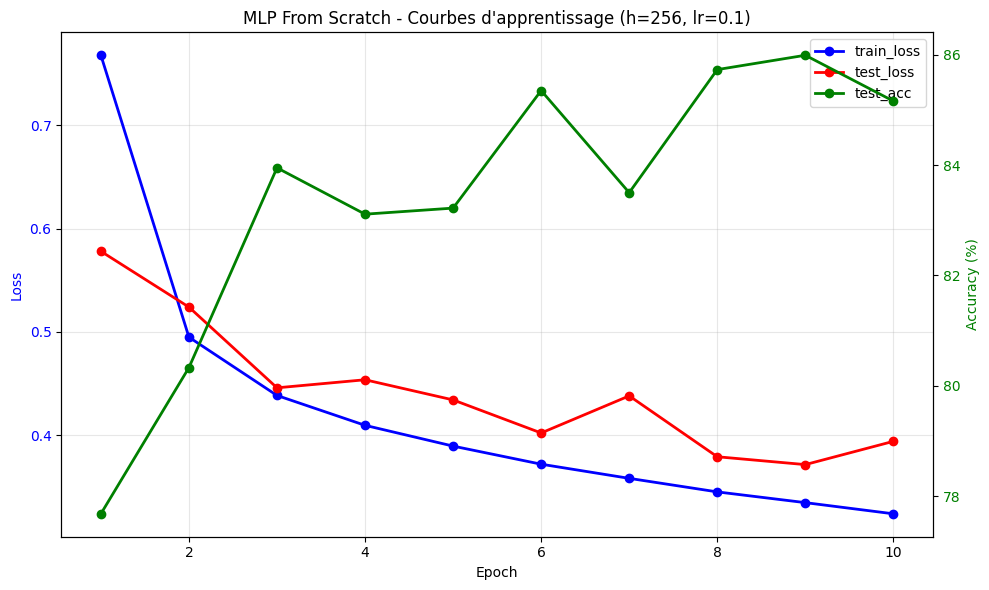

✅ Graphique from scratch sauvegardé dans figures/scratch_training_curves.png


In [17]:
import matplotlib.pyplot as plt

# Données from scratch
epochs = list(range(1, 11))
train_loss_scratch = [0.7677, 0.4949, 0.4385, 0.4096, 0.3895, 0.3720, 0.3583, 0.3452, 0.3348, 0.3240]
test_loss_scratch = [0.5780, 0.5240, 0.4459, 0.4537, 0.4342, 0.4022, 0.4381, 0.3792, 0.3716, 0.3941]
test_acc_scratch = [77.68, 80.33, 83.95, 83.11, 83.22, 85.35, 83.50, 85.73, 85.99, 85.16]

fig, ax1 = plt.subplots(figsize=(10, 6))

# Courbes de loss
ax1.plot(epochs, train_loss_scratch, 'b-o', label='train_loss', linewidth=2, markersize=6)
ax1.plot(epochs, test_loss_scratch, 'r-o', label='test_loss', linewidth=2, markersize=6)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right')

# Deuxième axe pour accuracy
ax2 = ax1.twinx()
ax2.plot(epochs, test_acc_scratch, 'g-o', label='test_acc', linewidth=2, markersize=6)
ax2.set_ylabel('Accuracy (%)', color='green')
ax2.tick_params(axis='y', labelcolor='green')

# Légende combinée
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title('MLP From Scratch - Courbes d\'apprentissage (h=256, lr=0.1)')
plt.tight_layout()
plt.savefig('figures/scratch_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphique from scratch sauvegardé dans figures/scratch_training_curves.png")

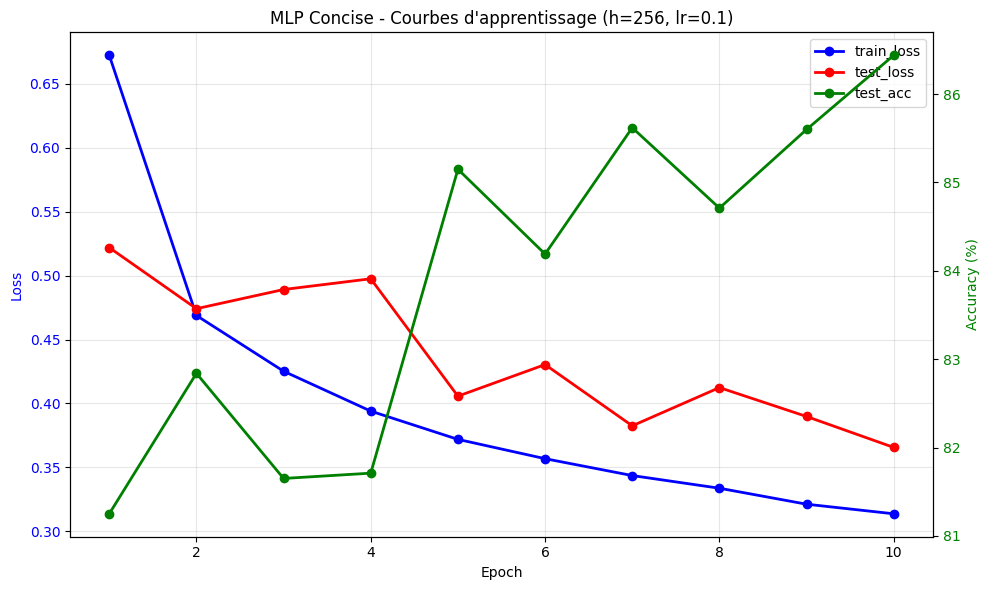

✅ Graphique concis sauvegardé dans figures/concise_training_curves.png


In [18]:
# Données concis
train_loss_concise = [0.6723, 0.4688, 0.4252, 0.3940, 0.3719, 0.3568, 0.3436, 0.3337, 0.3212, 0.3137]
test_loss_concise = [0.5219, 0.4741, 0.4891, 0.4975, 0.4057, 0.4304, 0.3825, 0.4124, 0.3898, 0.3656]
test_acc_concise = [81.25, 82.84, 81.65, 81.71, 85.15, 84.19, 85.62, 84.71, 85.60, 86.44]

fig, ax1 = plt.subplots(figsize=(10, 6))

# Courbes de loss
ax1.plot(epochs, train_loss_concise, 'b-o', label='train_loss', linewidth=2, markersize=6)
ax1.plot(epochs, test_loss_concise, 'r-o', label='test_loss', linewidth=2, markersize=6)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right')

# Deuxième axe pour accuracy
ax2 = ax1.twinx()
ax2.plot(epochs, test_acc_concise, 'g-o', label='test_acc', linewidth=2, markersize=6)
ax2.set_ylabel('Accuracy (%)', color='green')
ax2.tick_params(axis='y', labelcolor='green')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title('MLP Concise - Courbes d\'apprentissage (h=256, lr=0.1)')
plt.tight_layout()
plt.savefig('figures/concise_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphique concis sauvegardé dans figures/concise_training_curves.png")

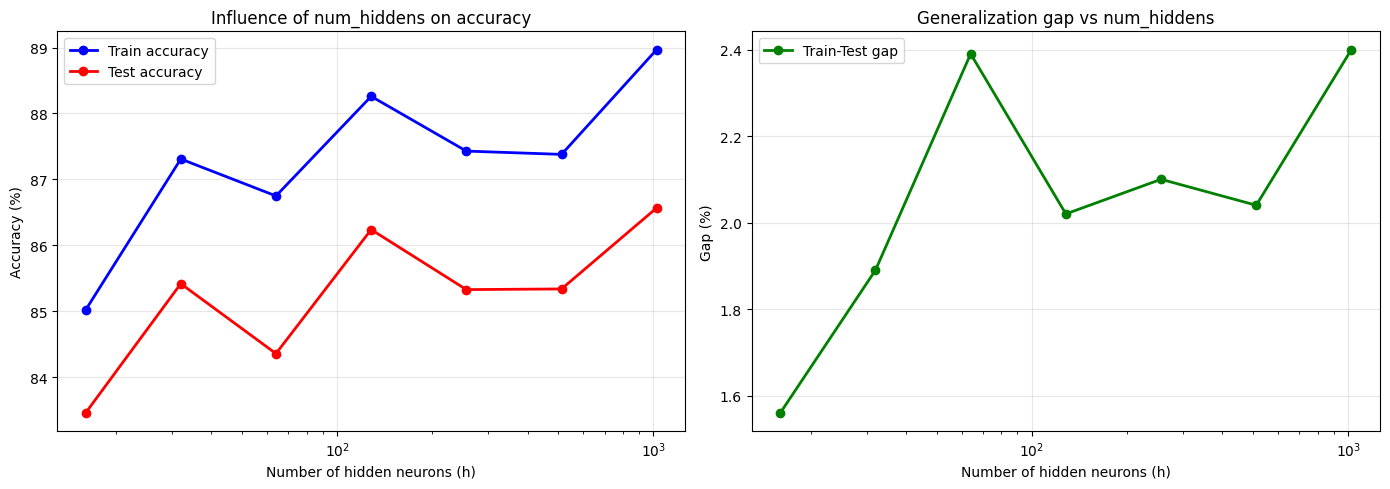

✅ Graphique variation num_hiddens sauvegardé dans figures/hidden_impact.png


In [19]:
# Données variation num_hiddens
h_values = [16, 32, 64, 128, 256, 512, 1024]
train_acc_hidden = [85.02, 87.31, 86.75, 88.26, 87.43, 87.38, 88.97]
test_acc_hidden = [83.46, 85.42, 84.36, 86.24, 85.33, 85.34, 86.57]
gap_hidden = [1.56, 1.89, 2.39, 2.02, 2.10, 2.04, 2.40]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1: Accuracy vs h
ax1.plot(h_values, train_acc_hidden, 'b-o', label='Train accuracy', linewidth=2, markersize=6)
ax1.plot(h_values, test_acc_hidden, 'r-o', label='Test accuracy', linewidth=2, markersize=6)
ax1.set_xlabel('Number of hidden neurons (h)')
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Influence of num_hiddens on accuracy')
ax1.set_xscale('log')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Graphique 2: Gap vs h
ax2.plot(h_values, gap_hidden, 'g-o', label='Train-Test gap', linewidth=2, markersize=6)
ax2.set_xlabel('Number of hidden neurons (h)')
ax2.set_ylabel('Gap (%)')
ax2.set_title('Generalization gap vs num_hiddens')
ax2.set_xscale('log')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.savefig('figures/hidden_impact.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphique variation num_hiddens sauvegardé dans figures/hidden_impact.png")

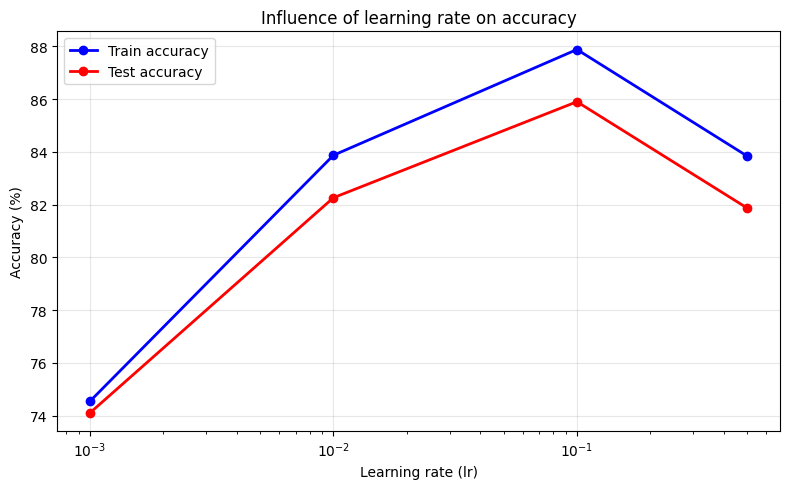

✅ Graphique variation learning rate sauvegardé dans figures/lr_impact.png


In [20]:
# Données variation learning rate
lr_values = [0.001, 0.01, 0.1, 0.5]
train_acc_lr = [74.54, 83.87, 87.88, 83.84]
test_acc_lr = [74.10, 82.26, 85.90, 81.87]

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(lr_values, train_acc_lr, 'b-o', label='Train accuracy', linewidth=2, markersize=6)
ax.plot(lr_values, test_acc_lr, 'r-o', label='Test accuracy', linewidth=2, markersize=6)
ax.set_xlabel('Learning rate (lr)')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Influence of learning rate on accuracy')
ax.set_xscale('log')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig('figures/lr_impact.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphique variation learning rate sauvegardé dans figures/lr_impact.png")

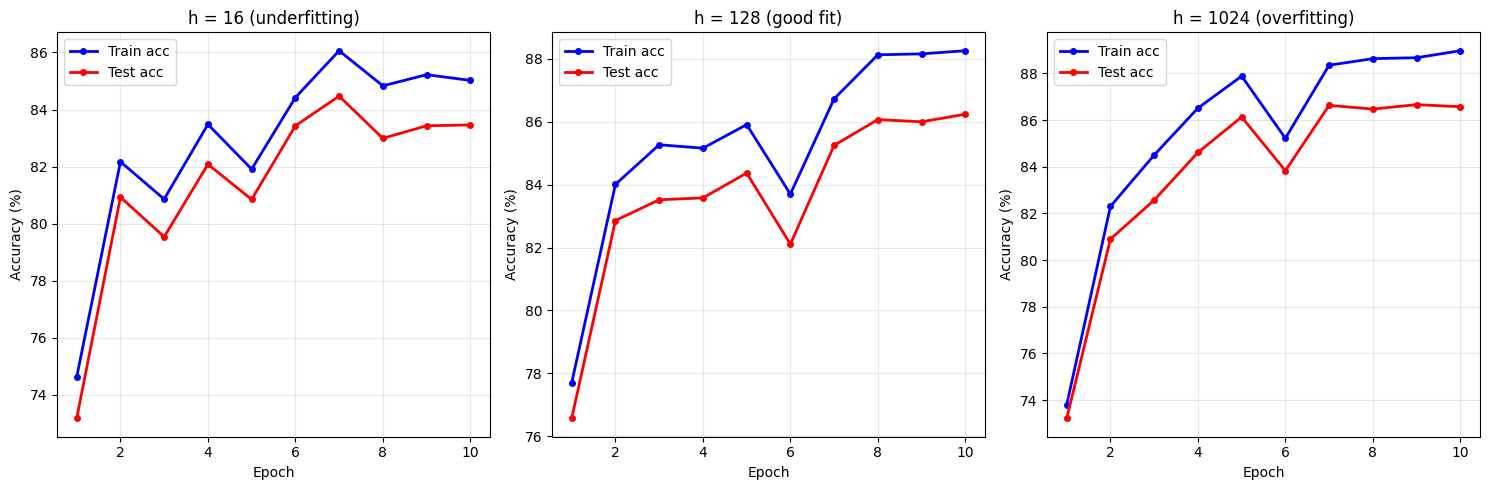

✅ Graphique train/test curves sauvegardé dans figures/train_test_curves.png


In [21]:
# Données pour plusieurs h (sélection des valeurs représentatives)
selected_h = [16, 128, 1024]

# Données par époque pour chaque h (à compléter avec vos résultats)
# Pour h=16 (d'après vos résultats)
epochs_full = list(range(1, 11))
train_acc_h16 = [74.63, 82.17, 80.86, 83.48, 81.91, 84.42, 86.06, 84.83, 85.22, 85.02]
test_acc_h16 = [73.18, 80.93, 79.54, 82.08, 80.85, 83.43, 84.47, 82.99, 83.43, 83.46]

# Pour h=128 (d'après vos résultats)
train_acc_h128 = [77.70, 84.01, 85.27, 85.16, 85.91, 83.70, 86.73, 88.13, 88.16, 88.26]
test_acc_h128 = [76.57, 82.86, 83.52, 83.58, 84.37, 82.11, 85.25, 86.07, 86.00, 86.24]

# Pour h=1024 (d'après vos résultats)
train_acc_h1024 = [73.80, 82.30, 84.50, 86.51, 87.88, 85.22, 88.35, 88.63, 88.67, 88.97]
test_acc_h1024 = [73.22, 80.90, 82.57, 84.61, 86.13, 83.83, 86.63, 86.47, 86.66, 86.57]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

colors = {'train': 'blue', 'test': 'red'}

# Graphique h=16
axes[0].plot(epochs_full, train_acc_h16, 'b-o', label='Train acc', linewidth=2, markersize=4)
axes[0].plot(epochs_full, test_acc_h16, 'r-o', label='Test acc', linewidth=2, markersize=4)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('h = 16 (underfitting)')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Graphique h=128
axes[1].plot(epochs_full, train_acc_h128, 'b-o', label='Train acc', linewidth=2, markersize=4)
axes[1].plot(epochs_full, test_acc_h128, 'r-o', label='Test acc', linewidth=2, markersize=4)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('h = 128 (good fit)')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# Graphique h=1024
axes[2].plot(epochs_full, train_acc_h1024, 'b-o', label='Train acc', linewidth=2, markersize=4)
axes[2].plot(epochs_full, test_acc_h1024, 'r-o', label='Test acc', linewidth=2, markersize=4)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Accuracy (%)')
axes[2].set_title('h = 1024 (overfitting)')
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.savefig('figures/train_test_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphique train/test curves sauvegardé dans figures/train_test_curves.png")

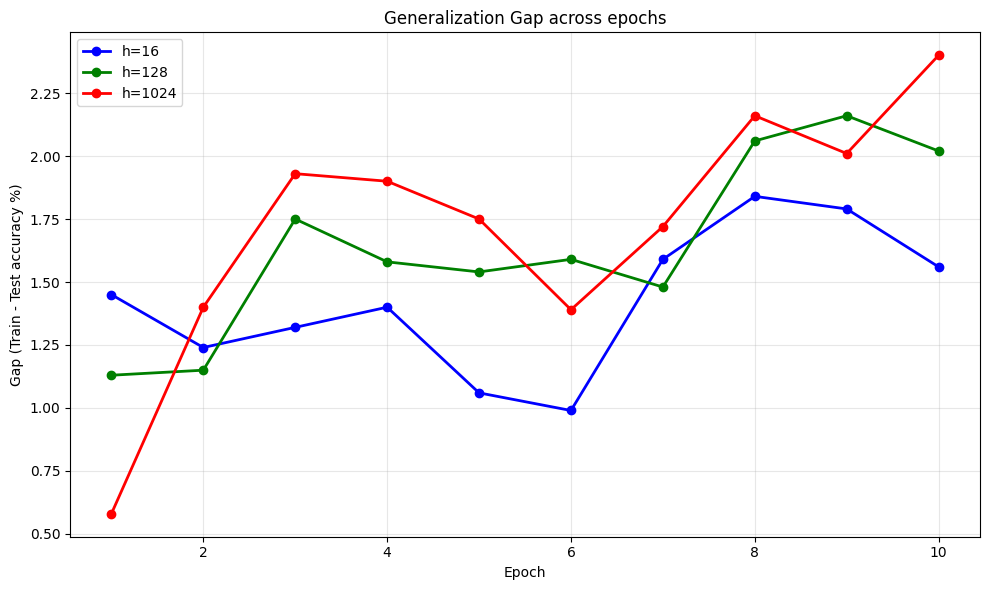

✅ Graphique gap evolution sauvegardé dans figures/gap_evolution.png


In [22]:
# Données gap par époque pour différentes capacités
gap_h16 = [t - s for t, s in zip(train_acc_h16, test_acc_h16)]
gap_h128 = [t - s for t, s in zip(train_acc_h128, test_acc_h128)]
gap_h1024 = [t - s for t, s in zip(train_acc_h1024, test_acc_h1024)]

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(epochs_full, gap_h16, 'b-o', label='h=16', linewidth=2, markersize=6)
ax.plot(epochs_full, gap_h128, 'g-o', label='h=128', linewidth=2, markersize=6)
ax.plot(epochs_full, gap_h1024, 'r-o', label='h=1024', linewidth=2, markersize=6)
ax.set_xlabel('Epoch')
ax.set_ylabel('Gap (Train - Test accuracy %)')
ax.set_title('Generalization Gap across epochs')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig('figures/gap_evolution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphique gap evolution sauvegardé dans figures/gap_evolution.png")

In [23]:
import os

print("="*60)
print("FICHIERS SAUVEGARDÉS")
print("="*60)

figures = [
    'figures/scratch_training_curves.png',
    'figures/concise_training_curves.png',
    'figures/hidden_impact.png',
    'figures/lr_impact.png',
    'figures/train_test_curves.png',
    'figures/gap_evolution.png'
]

for f in figures:
    if os.path.exists(f):
        print(f"✅ {f}")
    else:
        print(f"❌ {f} (manquant)")

FICHIERS SAUVEGARDÉS
✅ figures/scratch_training_curves.png
✅ figures/concise_training_curves.png
✅ figures/hidden_impact.png
✅ figures/lr_impact.png
✅ figures/train_test_curves.png
✅ figures/gap_evolution.png
